# Self-Reflective RAG 
This notebook implements the Self-Reflective / Corrective RAG graph, including document retrieval, relevance grading, query rewriting, web search fallback, and answer generation.

### 1. Imports & Environment Setup

In [1]:
import os
import json
import time
import re
from typing import List, TypedDict, Literal, Any, Dict
from dataclasses import dataclass, asdict
from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph, START, END

load_dotenv()

C:\Users\ayush\AppData\Local\Temp\ipykernel_10816\2278314731.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

### 2. Document Loading & Text Chunking

In [2]:
docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

chunks = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=150
).split_documents(docs)

incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams


### 3. LLM, Embeddings & Vector Store Setup

In [3]:
# Initialize Primary and Fallback LLMs
primary = ChatOpenAI(model="gpt-4o-mini", temperature=0.8)
fallback = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.8)
llm = primary.with_fallbacks([fallback])

# Vector Store & Retriever Setup
embeddings = OllamaEmbeddings(
    model="mxbai-embed-large",
    base_url="http://localhost:11434"
)
persist_directory = "./chroma_db"

if os.path.exists(persist_directory):
    print("Loading existing vector database...")
    vector_store = Chroma(
        persist_directory=persist_directory,
        embedding_function=embeddings,
        collection_name="company_knowledge_base"
    )
    if vector_store._collection.count() == 0:
        print("Vector database is empty or stale. Rebuilding from the source documents...")
        vector_store = Chroma.from_documents(
            documents=chunks,
            embedding=embeddings,
            persist_directory=persist_directory,
            collection_name="company_knowledge_base"
        )
else:
    print("Creating embeddings for the first time...")
    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name="company_knowledge_base"
    )

retriever = vector_store.as_retriever(search_kwargs={"k": 4})

Loading existing vector database...


### 4. Graph State & Tool Chains

In [4]:
class GraphState(TypedDict):
    question: str
    generation: str
    web_search: str
    documents: List[Document]

def web_search_tool():
    return DuckDuckGoSearchRun()

def rag_chain():
    prompt = PromptTemplate(
        template="""You are an assistant for question-answering tasks.
Use the following pieces of retrieved context and your knowledge to give a concise answer to the question.
If you don't know the answer, just say that you don't know.
Question: {question}
Context: {context}
Answer:""",
        input_variables=["question", "context"],
    )
    return prompt | llm | StrOutputParser()

def retrieval_grader():
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question.
Here is the retrieved document:

{document}

Here is the user question: {question}
If the document contains keywords related to the user question, grade it as relevant.
It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
Provide the binary score as a JSON with a single key 'score' and no preamble or explanation.""",
        input_variables=["question", "document"],
    )
    return prompt | llm | JsonOutputParser()

def question_rewriter():
    re_write_prompt = PromptTemplate(
        template="""You are a question re-writer that converts an input question to a better
and simpler version that is optimized for vector database retrieval.
Look at the initial question and formulate an improved yet simpler question.
Here is the initial question:

{question}
Improved question with no preamble:
""",
        input_variables=["question"],
    )
    return re_write_prompt | llm | StrOutputParser()

### 5. Graph Nodes & Routing Logic

In [5]:
def retrieve(state: GraphState):
    print("---RETRIEVING DOCUMENTS---")
    question = state["question"]
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

def grade_documents(state: GraphState):
    print("---CHECKING DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]
    filtered_docs = []
    web_search_flag = "No"
    grader = retrieval_grader()
    
    for d in documents:
        score = grader.invoke({"question": question, "document": d.page_content})
        grade = score.get("score", "").lower()
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search_flag = "Yes"
            
    return {"documents": filtered_docs, "question": question, "web_search": web_search_flag}

def generate(state: GraphState):
    print("---GENERATING ANSWER---")
    question = state["question"]
    documents = state["documents"]
    
    formatted_docs = "\n\n".join(doc.page_content for doc in documents)
    chain = rag_chain()
    generation = chain.invoke({"context": formatted_docs, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

def transform_query(state: GraphState):
    print("---TRANSFORMING / REWRITING QUERY---")
    question = state["question"]
    documents = state["documents"]
    
    better_question = question_rewriter().invoke({"question": question})
    return {"documents": documents, "question": better_question}

def web_search(state: GraphState):
    print("---RUNNING WEB SEARCH---")
    question = state["question"]
    documents = state.get("documents", [])
    web_results = str(web_search_tool().run(question))
    web_doc = Document(page_content=web_results, metadata={"source": "Web Search"})
    documents.append(web_doc)
    return {"documents": documents, "question": question}

def decide_to_generate(state: GraphState):
    print("---DECIDING NEXT STEP---")
    web_search_flag = state["web_search"]
    if web_search_flag == "Yes":
        print("---DECISION: NOT ALL DOCUMENTS RELEVANT, TRANSFORMING QUERY---")
        return "transform_query"
    else:
        print("---DECISION: ALL DOCUMENTS RELEVANT, GENERATING ANSWER---")
        return "generate"

### 6. Build & Compile LangGraph Workflow

In [6]:
workflow = StateGraph(GraphState)

# Define nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)
workflow.add_node("web_search", web_search)

# Build graph structure
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate"
    }
)
workflow.add_edge("transform_query", "web_search")
workflow.add_edge("web_search", "generate")
workflow.add_edge("generate", END)

# Compile graph
app = workflow.compile()

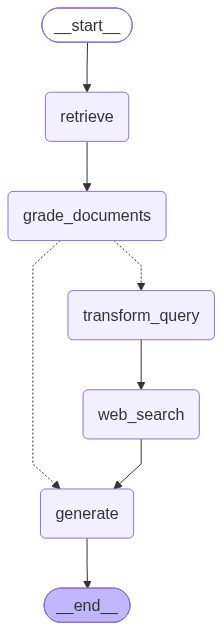

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

### 7. Run & Test Pipeline

In [8]:
inputs = {"question": "Who is the CEO of NexaAI?"}
for output in app.stream(inputs):
    for key, value in output.items():
        print(f"Finished Running Node: {key}")

print("\n--- FINAL ANSWER ---")
print(value.get("generation"))

---RETRIEVING DOCUMENTS---
Finished Running Node: retrieve
---CHECKING DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---DECIDING NEXT STEP---
---DECISION: NOT ALL DOCUMENTS RELEVANT, TRANSFORMING QUERY---
Finished Running Node: grade_documents
---TRANSFORMING / REWRITING QUERY---
Finished Running Node: transform_query
---RUNNING WEB SEARCH---
Finished Running Node: web_search
---GENERATING ANSWER---
Finished Running Node: generate

--- FINAL ANSWER ---
The CEO of NexaAI is Alex (Wei) Chen.
